# CIFAR-100 Hyperparameter Grid Search
## COMP34212 Cognitive Robotics - Deep Learning Coursework

This notebook systematically explores the effect of three hyperparameters on CNN performance for CIFAR-100 image classification:

1. **Learning Rate**: 0.1, 0.01, 0.001, 0.0001
2. **Dropout Rate**: 0.0, 0.25, 0.5
3. **Network Depth**: 2, 4, 6 convolutional layers

Full grid search: 4 × 3 × 3 = 36 configurations, each trained for 50 epochs.

## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
import json
import itertools
from collections import defaultdict

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA L40S


## 2. Hyperparameter Grid Definition

In [2]:
# Hyperparameter grid
LEARNING_RATES = [0.1, 0.01, 0.001, 0.0001]
DROPOUT_RATES = [0.0, 0.25, 0.5]
DEPTHS = [2, 4, 6]  # Number of convolutional layers

# Fixed hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 50
OPTIMIZER = 'Adam'
NUM_CLASSES = 100

# Generate all combinations
grid = list(itertools.product(LEARNING_RATES, DROPOUT_RATES, DEPTHS))
print(f'Total configurations: {len(grid)}')
print(f'Estimated time at ~15 min/run: {len(grid) * 15 / 60:.1f} hours')

Total configurations: 36
Estimated time at ~15 min/run: 9.0 hours


## 3. Data Loading and Preprocessing

In [ ]:
# Data augmentation for training (baseline augmentation applied to all runs)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5071, 0.4867, 0.4408],
        std=[0.2675, 0.2565, 0.2761]
    ),
])

# No augmentation for validation and test
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5071, 0.4867, 0.4408],
        std=[0.2675, 0.2565, 0.2761]
    ),
])

# Download CIFAR-100
full_train_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_train
)
full_train_dataset_no_aug = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform_test
)
test_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform_test
)

# Split training set into train (45k) and validation (5k)
num_train = len(full_train_dataset)
indices = list(range(num_train))
np.random.shuffle(indices)
train_indices = indices[:45000]
val_indices = indices[45000:]

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset_no_aug, val_indices)

print(f'Training set size: {len(train_dataset)}')
print(f'Validation set size: {len(val_dataset)}')
print(f'Test set size: {len(test_dataset)}')

## 4. CNN Architecture (Variable Depth)

In [4]:
class FlexibleCNN(nn.Module):
    """
    A CNN with configurable depth (number of convolutional layers) and dropout.
    
    Architecture:
    - Convolutional layers are organised in blocks, each block containing:
      Conv2d -> BatchNorm -> ReLU
    - MaxPooling is applied after every 2 conv layers
    - Base filter count is 64, doubling after each pooling operation
    - Followed by an adaptive average pooling, then fully connected layers
    """
    
    def __init__(self, num_layers=4, dropout_rate=0.25, num_classes=100):
        super(FlexibleCNN, self).__init__()
        
        self.num_layers = num_layers
        self.dropout_rate = dropout_rate
        
        layers = []
        in_channels = 3
        base_filters = 64
        current_filters = base_filters
        
        for i in range(num_layers):
            # Convolutional layer with batch normalisation and ReLU
            layers.append(nn.Conv2d(in_channels, current_filters, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(current_filters))
            layers.append(nn.ReLU(inplace=True))
            
            in_channels = current_filters
            
            # Pool after every 2 conv layers and double filters
            if (i + 1) % 2 == 0:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
                if current_filters < 512:  # Cap at 512 filters
                    current_filters *= 2
        
        # If odd number of layers, add a final pooling
        if num_layers % 2 != 0:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        
        self.features = nn.Sequential(*layers)
        
        # Adaptive pooling ensures a fixed output size regardless of depth
        self.adaptive_pool = nn.AdaptiveAvgPool2d((2, 2))
        
        # Classifier
        classifier_input = in_channels * 2 * 2
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(classifier_input, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# Verify architecture for each depth
for depth in DEPTHS:
    model = FlexibleCNN(num_layers=depth, dropout_rate=0.25, num_classes=100)
    total_params = sum(p.numel() for p in model.parameters())
    dummy = torch.randn(1, 3, 32, 32)
    out = model(dummy)
    print(f'Depth {depth}: {total_params:,} parameters, output shape: {out.shape}')

Depth 2: 221,860 parameters, output shape: torch.Size([1, 100])
Depth 4: 574,884 parameters, output shape: torch.Size([1, 100])
Depth 6: 1,723,300 parameters, output shape: torch.Size([1, 100])


## 5. Training and Evaluation Functions

In [5]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch and return average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    return running_loss / total, 100.0 * correct / total


def evaluate(model, data_loader, criterion, device):
    """Evaluate and return average loss and accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return running_loss / total, 100.0 * correct / total

In [6]:
def run_experiment(lr, dropout_rate, depth, train_dataset, val_dataset,
                   batch_size, num_epochs, device, num_classes=100):
    """
    Train a single configuration and return the full training history.
    """
    # Reset seed for each run for fair comparison
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    np.random.seed(SEED)
    
    # Data loaders
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )
    
    # Create model
    model = FlexibleCNN(
        num_layers=depth, dropout_rate=dropout_rate, num_classes=num_classes
    ).to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'epoch_time': [],
    }
    
    config_str = f'LR={lr}, Dropout={dropout_rate}, Depth={depth}'
    print(f'\n{"="*60}')
    print(f'Training: {config_str}')
    print(f'{"="*60}')
    
    total_start = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        epoch_time = time.time() - epoch_start
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1:3d}/{num_epochs}] '
                  f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | '
                  f'Time: {epoch_time:.1f}s')
    
    total_time = time.time() - total_start
    history['total_time'] = total_time
    
    print(f'\nTotal training time: {total_time/60:.1f} minutes')
    print(f'Best validation accuracy: {max(history["val_acc"]):.2f}% '
          f'(epoch {np.argmax(history["val_acc"])+1})')
    
    return history, model

## 6. Run Grid Search

In [7]:
# Directory to save results
os.makedirs('results', exist_ok=True)

# Store all results
all_results = {}

total_start = time.time()

for i, (lr, dropout, depth) in enumerate(grid):
    config_key = f'lr{lr}_drop{dropout}_depth{depth}'
    print(f'\n>>> Configuration {i+1}/{len(grid)}: {config_key}')
    
    history, model = run_experiment(
        lr=lr,
        dropout_rate=dropout,
        depth=depth,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        batch_size=BATCH_SIZE,
        num_epochs=NUM_EPOCHS,
        device=device,
        num_classes=NUM_CLASSES
    )
    
    # Store results with config info
    all_results[config_key] = {
        'lr': lr,
        'dropout': dropout,
        'depth': depth,
        'history': history,
        'best_val_acc': max(history['val_acc']),
        'best_val_epoch': int(np.argmax(history['val_acc'])) + 1,
        'final_val_acc': history['val_acc'][-1],
        'final_train_acc': history['train_acc'][-1],
        'total_time': history['total_time'],
    }
    
    # Save checkpoint after each run (in case of interruption)
    with open('results/grid_search_results.json', 'w') as f:
        # Convert for JSON serialisation
        json_results = {}
        for k, v in all_results.items():
            json_results[k] = {
                'lr': v['lr'],
                'dropout': v['dropout'],
                'depth': v['depth'],
                'best_val_acc': v['best_val_acc'],
                'best_val_epoch': v['best_val_epoch'],
                'final_val_acc': v['final_val_acc'],
                'final_train_acc': v['final_train_acc'],
                'total_time': v['total_time'],
                'history': v['history'],
            }
        json.dump(json_results, f, indent=2)
    
    # Clear GPU memory
    del model
    torch.cuda.empty_cache()

total_grid_time = time.time() - total_start
print(f'\n{"="*60}')
print(f'Grid search complete! Total time: {total_grid_time/3600:.1f} hours')
print(f'{"="*60}')


>>> Configuration 1/36: lr0.1_drop0.0_depth2



Training: LR=0.1, Dropout=0.0, Depth=2


Epoch [  1/50] Train Loss: 5.4152 | Train Acc: 4.04% | Val Loss: 4.1530 | Val Acc: 5.18% | Time: 15.2s


Epoch [ 10/50] Train Loss: 4.0104 | Train Acc: 6.40% | Val Loss: 4.2427 | Val Acc: 5.64% | Time: 3.7s


Epoch [ 20/50] Train Loss: 3.9408 | Train Acc: 7.50% | Val Loss: 3.9745 | Val Acc: 7.12% | Time: 3.6s


...

Epoch [ 10/50] Train Loss: 2.4047 | Train Acc: 36.11% | Val Loss: 2.2227 | Val Acc: 40.68% | Time: 3.6s


Epoch [ 20/50] Train Loss: 1.9107 | Train Acc: 47.27% | Val Loss: 1.8646 | Val Acc: 49.90% | Time: 3.5s


Epoch [ 30/50] Train Loss: 1.6646 | Train Acc: 53.21% | Val Loss: 1.6537 | Val Acc: 54.72% | Time: 3.5s


Epoch [ 40/50] Train Loss: 1.4830 | Train Acc: 57.42% | Val Loss: 1.5879 | Val Acc: 56.70% | Time: 3.6s


Epoch [ 50/50] Train Loss: 1.3534 | Train Acc: 60.49% | Val Loss: 1.5911 | Val Acc: 57.60% | Time: 3.6s

Total training time: 3.0 minutes
Best validation accuracy: 58.48% (epoch 48)

Grid search complete! Total time: 1.8 hours


## 7. Results Summary Table

In [8]:
# Build summary DataFrame
rows = []
for config_key, result in all_results.items():
    rows.append({
        'Learning Rate': result['lr'],
        'Dropout Rate': result['dropout'],
        'Depth': result['depth'],
        'Best Val Acc (%)': round(result['best_val_acc'], 2),
        'Best Epoch': result['best_val_epoch'],
        'Final Val Acc (%)': round(result['final_val_acc'], 2),
        'Final Train Acc (%)': round(result['final_train_acc'], 2),
        'Train-Val Gap (%)': round(result['final_train_acc'] - result['final_val_acc'], 2),
        'Training Time (min)': round(result['total_time'] / 60, 1),
    })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values('Best Val Acc (%)', ascending=False).reset_index(drop=True)

print('=== All Results Sorted by Best Validation Accuracy ===')
print(df_results.to_string())

print(f'\n=== Top 5 Configurations ===')
print(df_results.head(5).to_string())

print(f'\n=== Bottom 5 Configurations ===')
print(df_results.tail(5).to_string())

=== All Results Sorted by Best Validation Accuracy ===
    Learning Rate  Dropout Rate  Depth  Best Val Acc (%)  Best Epoch  Final Val Acc (%)  Final Train Acc (%)  Train-Val Gap (%)  Training Time (min)
0          0.0010          0.25      6             65.30          50              65.30                79.16              13.86                  3.0
1          0.0010          0.50      6             64.10          46              63.56                71.20               7.64                  3.0
2          0.0010          0.00      6             63.24          41              63.08                91.56              28.48                  3.0
3          0.0001          0.25      6             61.20          47              60.50                69.74               9.24                  3.0
4          0.0001          0.00      6             60.78          48              60.20                80.83              20.63                  3.0
5          0.0010          0.25      4             

## 8. Visualisation: Training Curves

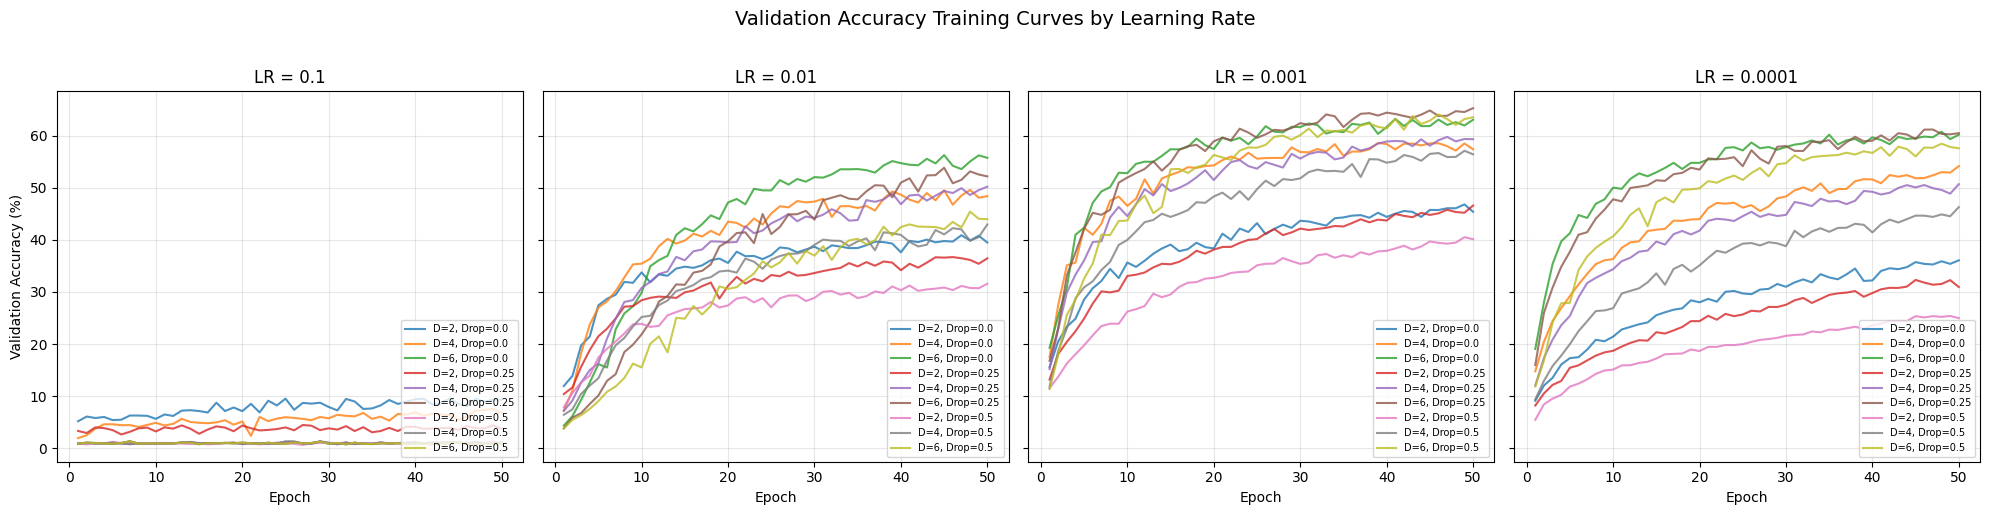

In [9]:
def plot_training_curves_by_lr(all_results):
    """
    Plot training curves grouped by learning rate.
    One subplot per learning rate showing val accuracy for all depth/dropout combos.
    """
    fig, axes = plt.subplots(1, len(LEARNING_RATES), figsize=(20, 5), sharey=True)
    fig.suptitle('Validation Accuracy Training Curves by Learning Rate', fontsize=14, y=1.02)
    
    for ax, lr in zip(axes, LEARNING_RATES):
        for config_key, result in all_results.items():
            if result['lr'] == lr:
                label = f"D={result['depth']}, Drop={result['dropout']}"
                ax.plot(range(1, NUM_EPOCHS+1), result['history']['val_acc'], label=label, alpha=0.8)
        
        ax.set_title(f'LR = {lr}')
        ax.set_xlabel('Epoch')
        if ax == axes[0]:
            ax.set_ylabel('Validation Accuracy (%)')
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/training_curves_by_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves_by_lr(all_results)

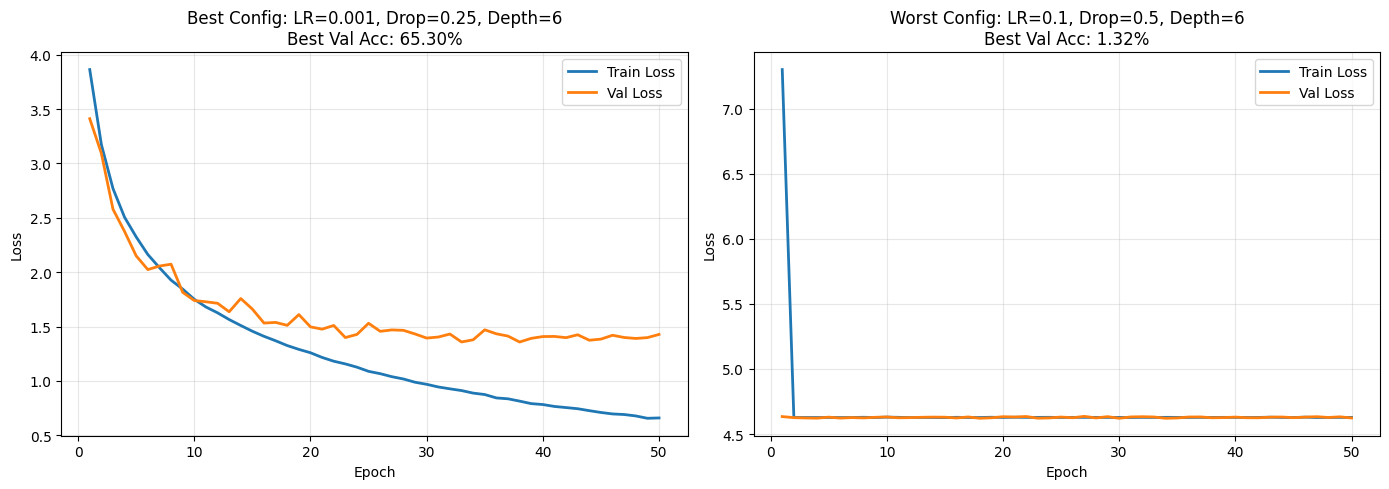

In [10]:
def plot_loss_curves_best_vs_worst(all_results):
    """
    Plot train and val loss curves for the best and worst configurations.
    """
    sorted_configs = sorted(all_results.items(), key=lambda x: x[1]['best_val_acc'], reverse=True)
    best_key, best = sorted_configs[0]
    worst_key, worst = sorted_configs[-1]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, NUM_EPOCHS+1)
    
    # Best configuration
    axes[0].plot(epochs, best['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(epochs, best['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_title(f'Best Config: LR={best["lr"]}, Drop={best["dropout"]}, Depth={best["depth"]}\n'
                      f'Best Val Acc: {best["best_val_acc"]:.2f}%')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Worst configuration
    axes[1].plot(epochs, worst['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[1].plot(epochs, worst['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title(f'Worst Config: LR={worst["lr"]}, Drop={worst["dropout"]}, Depth={worst["depth"]}\n'
                      f'Best Val Acc: {worst["best_val_acc"]:.2f}%')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/loss_curves_best_worst.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_loss_curves_best_vs_worst(all_results)

## 9. Visualisation: Individual Hyperparameter Effects

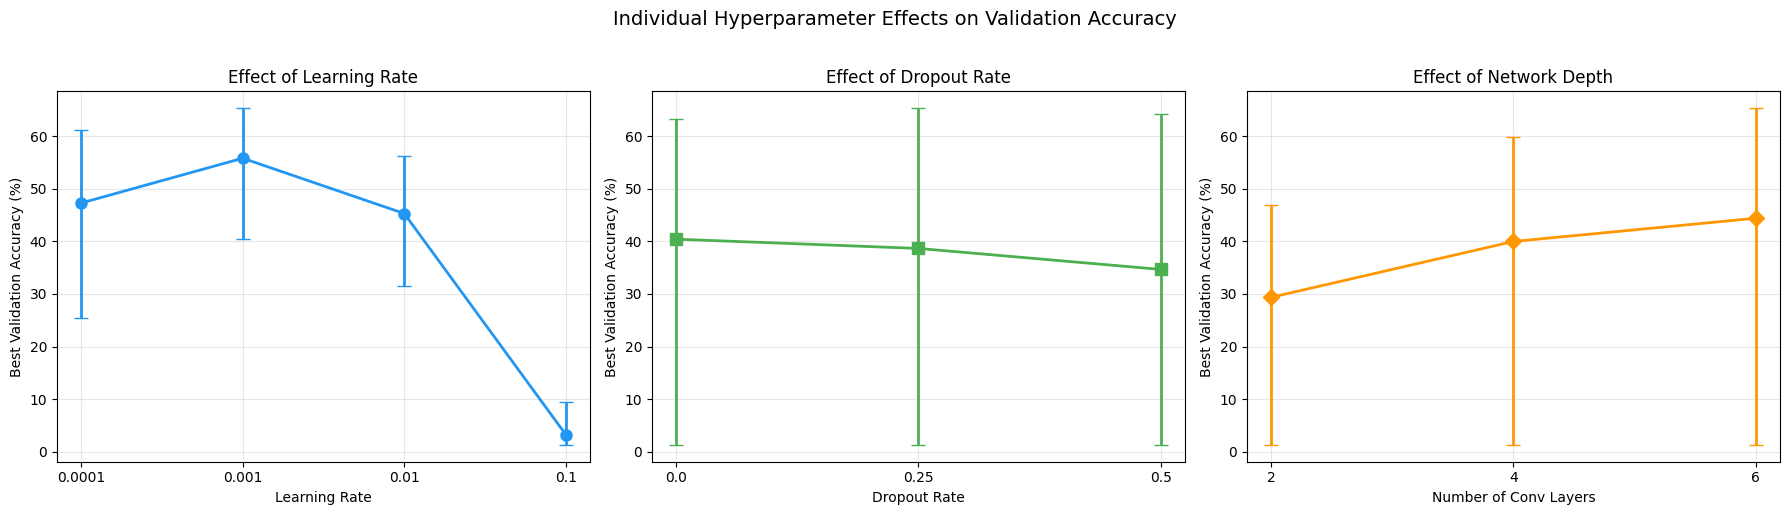

In [11]:
def plot_individual_effects(df_results):
    """
    Plot the isolated effect of each hyperparameter on best validation accuracy.
    Each point shows mean accuracy across all other hyperparameter values;
    error bars show min-max range.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Individual Hyperparameter Effects on Validation Accuracy', fontsize=14, y=1.02)
    
    # Learning Rate
    lr_stats = df_results.groupby('Learning Rate')['Best Val Acc (%)'].agg(['mean', 'min', 'max'])
    axes[0].errorbar(
        range(len(lr_stats)), lr_stats['mean'],
        yerr=[lr_stats['mean'] - lr_stats['min'], lr_stats['max'] - lr_stats['mean']],
        fmt='o-', capsize=5, linewidth=2, markersize=8, color='#2196F3'
    )
    axes[0].set_xticks(range(len(lr_stats)))
    axes[0].set_xticklabels([str(x) for x in lr_stats.index])
    axes[0].set_xlabel('Learning Rate')
    axes[0].set_ylabel('Best Validation Accuracy (%)')
    axes[0].set_title('Effect of Learning Rate')
    axes[0].grid(True, alpha=0.3)
    
    # Dropout Rate
    drop_stats = df_results.groupby('Dropout Rate')['Best Val Acc (%)'].agg(['mean', 'min', 'max'])
    axes[1].errorbar(
        range(len(drop_stats)), drop_stats['mean'],
        yerr=[drop_stats['mean'] - drop_stats['min'], drop_stats['max'] - drop_stats['mean']],
        fmt='s-', capsize=5, linewidth=2, markersize=8, color='#4CAF50'
    )
    axes[1].set_xticks(range(len(drop_stats)))
    axes[1].set_xticklabels([str(x) for x in drop_stats.index])
    axes[1].set_xlabel('Dropout Rate')
    axes[1].set_ylabel('Best Validation Accuracy (%)')
    axes[1].set_title('Effect of Dropout Rate')
    axes[1].grid(True, alpha=0.3)
    
    # Depth
    depth_stats = df_results.groupby('Depth')['Best Val Acc (%)'].agg(['mean', 'min', 'max'])
    axes[2].errorbar(
        range(len(depth_stats)), depth_stats['mean'],
        yerr=[depth_stats['mean'] - depth_stats['min'], depth_stats['max'] - depth_stats['mean']],
        fmt='D-', capsize=5, linewidth=2, markersize=8, color='#FF9800'
    )
    axes[2].set_xticks(range(len(depth_stats)))
    axes[2].set_xticklabels([str(x) for x in depth_stats.index])
    axes[2].set_xlabel('Number of Conv Layers')
    axes[2].set_ylabel('Best Validation Accuracy (%)')
    axes[2].set_title('Effect of Network Depth')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/individual_effects.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_individual_effects(df_results)

## 10. Visualisation: Pairwise Interaction Heatmaps

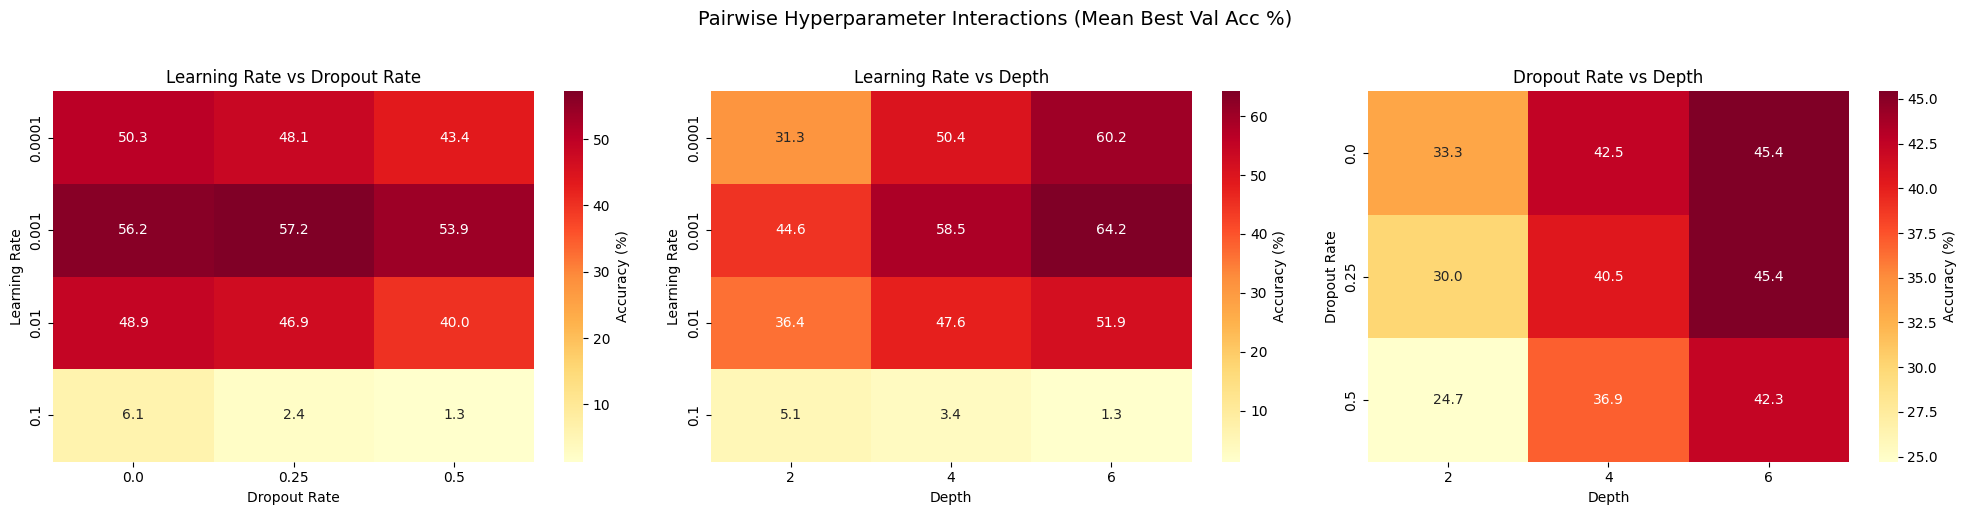

In [12]:
def plot_interaction_heatmaps(df_results):
    """
    Plot 2D heatmaps for each pair of hyperparameters,
    averaging over the third hyperparameter.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle('Pairwise Hyperparameter Interactions (Mean Best Val Acc %)', fontsize=14, y=1.02)
    
    # LR vs Dropout (averaged over Depth)
    pivot1 = df_results.pivot_table(
        values='Best Val Acc (%)', index='Learning Rate',
        columns='Dropout Rate', aggfunc='mean'
    )
    sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Accuracy (%)'})
    axes[0].set_title('Learning Rate vs Dropout Rate')
    
    # LR vs Depth (averaged over Dropout)
    pivot2 = df_results.pivot_table(
        values='Best Val Acc (%)', index='Learning Rate',
        columns='Depth', aggfunc='mean'
    )
    sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Accuracy (%)'})
    axes[1].set_title('Learning Rate vs Depth')
    
    # Dropout vs Depth (averaged over LR)
    pivot3 = df_results.pivot_table(
        values='Best Val Acc (%)', index='Dropout Rate',
        columns='Depth', aggfunc='mean'
    )
    sns.heatmap(pivot3, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[2], cbar_kws={'label': 'Accuracy (%)'})
    axes[2].set_title('Dropout Rate vs Depth')
    
    plt.tight_layout()
    plt.savefig('results/interaction_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_interaction_heatmaps(df_results)

## 11. Visualisation: Training Time Analysis

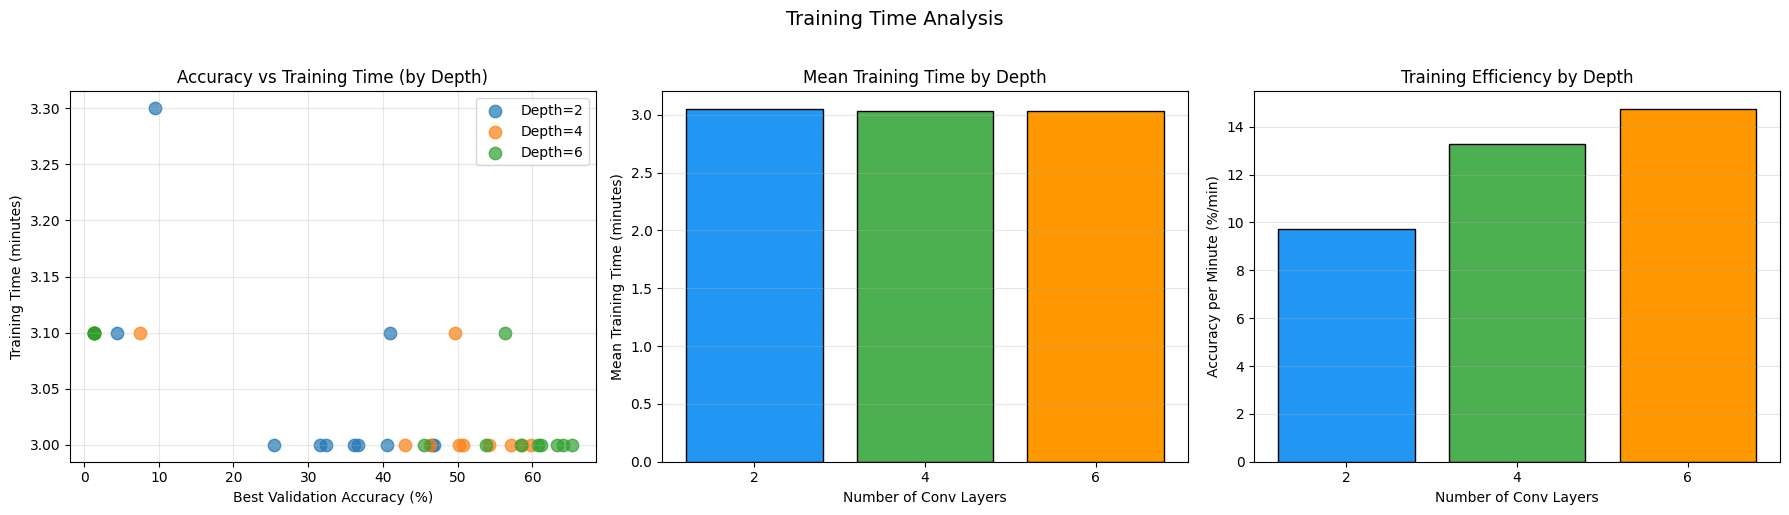

In [13]:
def plot_training_time(df_results):
    """
    Plot training time across configurations and its relationship with accuracy.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Training Time Analysis', fontsize=14, y=1.02)
    
    # Training time by depth
    for depth in DEPTHS:
        subset = df_results[df_results['Depth'] == depth]
        axes[0].scatter(
            subset['Best Val Acc (%)'], subset['Training Time (min)'],
            label=f'Depth={depth}', s=80, alpha=0.7
        )
    axes[0].set_xlabel('Best Validation Accuracy (%)')
    axes[0].set_ylabel('Training Time (minutes)')
    axes[0].set_title('Accuracy vs Training Time (by Depth)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Mean training time by depth
    time_by_depth = df_results.groupby('Depth')['Training Time (min)'].mean()
    axes[1].bar(
        [str(d) for d in time_by_depth.index], time_by_depth.values,
        color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='black'
    )
    axes[1].set_xlabel('Number of Conv Layers')
    axes[1].set_ylabel('Mean Training Time (minutes)')
    axes[1].set_title('Mean Training Time by Depth')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Efficiency: accuracy per minute of training
    df_results_copy = df_results.copy()
    df_results_copy['Efficiency'] = (
        df_results_copy['Best Val Acc (%)'] / df_results_copy['Training Time (min)']
    )
    eff_by_depth = df_results_copy.groupby('Depth')['Efficiency'].mean()
    axes[2].bar(
        [str(d) for d in eff_by_depth.index], eff_by_depth.values,
        color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='black'
    )
    axes[2].set_xlabel('Number of Conv Layers')
    axes[2].set_ylabel('Accuracy per Minute (%/min)')
    axes[2].set_title('Training Efficiency by Depth')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('results/training_time_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_time(df_results)

## 12. Visualisation: Overfitting Analysis

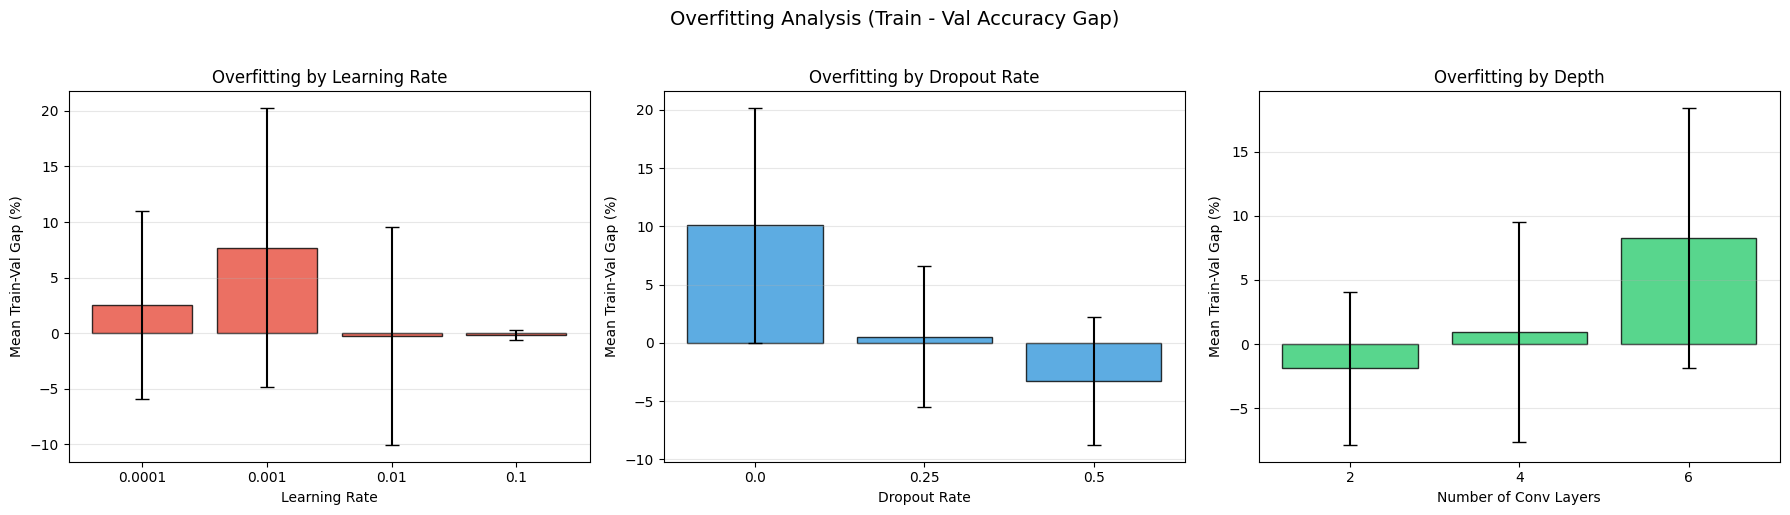

In [14]:
def plot_overfitting_analysis(df_results):
    """
    Plot the train-validation accuracy gap to visualise overfitting
    across different hyperparameter settings.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Overfitting Analysis (Train - Val Accuracy Gap)', fontsize=14, y=1.02)
    
    # Gap by Learning Rate
    gap_by_lr = df_results.groupby('Learning Rate')['Train-Val Gap (%)'].agg(['mean', 'std'])
    axes[0].bar(
        [str(x) for x in gap_by_lr.index], gap_by_lr['mean'],
        yerr=gap_by_lr['std'], capsize=5, color='#e74c3c', edgecolor='black', alpha=0.8
    )
    axes[0].set_xlabel('Learning Rate')
    axes[0].set_ylabel('Mean Train-Val Gap (%)')
    axes[0].set_title('Overfitting by Learning Rate')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Gap by Dropout
    gap_by_drop = df_results.groupby('Dropout Rate')['Train-Val Gap (%)'].agg(['mean', 'std'])
    axes[1].bar(
        [str(x) for x in gap_by_drop.index], gap_by_drop['mean'],
        yerr=gap_by_drop['std'], capsize=5, color='#3498db', edgecolor='black', alpha=0.8
    )
    axes[1].set_xlabel('Dropout Rate')
    axes[1].set_ylabel('Mean Train-Val Gap (%)')
    axes[1].set_title('Overfitting by Dropout Rate')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Gap by Depth
    gap_by_depth = df_results.groupby('Depth')['Train-Val Gap (%)'].agg(['mean', 'std'])
    axes[2].bar(
        [str(x) for x in gap_by_depth.index], gap_by_depth['mean'],
        yerr=gap_by_depth['std'], capsize=5, color='#2ecc71', edgecolor='black', alpha=0.8
    )
    axes[2].set_xlabel('Number of Conv Layers')
    axes[2].set_ylabel('Mean Train-Val Gap (%)')
    axes[2].set_title('Overfitting by Depth')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('results/overfitting_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_overfitting_analysis(df_results)

## 13. Final Test Evaluation (Best Configuration)

In [15]:
# Identify best configuration
best_config = max(all_results.values(), key=lambda x: x['best_val_acc'])
print(f'Best configuration:')
print(f'  Learning Rate: {best_config["lr"]}')
print(f'  Dropout Rate:  {best_config["dropout"]}')
print(f'  Depth:         {best_config["depth"]}')
print(f'  Best Val Acc:  {best_config["best_val_acc"]:.2f}%')

# Retrain best configuration and evaluate on test set
print(f'\nRetraining best configuration for final test evaluation...')

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

best_model = FlexibleCNN(
    num_layers=best_config['depth'],
    dropout_rate=best_config['dropout'],
    num_classes=NUM_CLASSES
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=best_config['lr'])

# Train on full training set (45k) for the same number of epochs
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        best_model, train_loader, criterion, optimizer, device
    )
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')

# Final test evaluation
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f'\n{"="*60}')
print(f'FINAL TEST ACCURACY: {test_acc:.2f}%')
print(f'Test Loss: {test_loss:.4f}')
print(f'{"="*60}')

Best configuration:
  Learning Rate: 0.001
  Dropout Rate:  0.25
  Depth:         6
  Best Val Acc:  65.30%

Retraining best configuration for final test evaluation...


Epoch [10/50] Train Loss: 1.7514 | Train Acc: 50.92%


Epoch [20/50] Train Loss: 1.2574 | Train Acc: 62.79%


Epoch [30/50] Train Loss: 0.9717 | Train Acc: 70.58%


Epoch [40/50] Train Loss: 0.7746 | Train Acc: 75.68%


Epoch [50/50] Train Loss: 0.6529 | Train Acc: 79.32%



FINAL TEST ACCURACY: 65.26%
Test Loss: 1.3811


## 14. Export Results Summary

In [16]:
# Save the full results DataFrame as CSV
df_results.to_csv('results/full_results_table.csv', index=False)

# Print a summary suitable for inclusion in the report
print('=== Summary Statistics ===')
print(f'Total configurations tested: {len(df_results)}')
print(f'Total grid search time: {total_grid_time/3600:.1f} hours')
print(f'\nBest validation accuracy: {df_results["Best Val Acc (%)"].max():.2f}%')
print(f'Worst validation accuracy: {df_results["Best Val Acc (%)"].min():.2f}%')
print(f'Mean validation accuracy: {df_results["Best Val Acc (%)"].mean():.2f}%')
print(f'Std validation accuracy: {df_results["Best Val Acc (%)"].std():.2f}%')
print(f'\nFinal test accuracy (best config): {test_acc:.2f}%')

print('\n=== Mean Accuracy by Hyperparameter ===')
print('\nBy Learning Rate:')
print(df_results.groupby('Learning Rate')['Best Val Acc (%)'].mean().to_string())
print('\nBy Dropout Rate:')
print(df_results.groupby('Dropout Rate')['Best Val Acc (%)'].mean().to_string())
print('\nBy Depth:')
print(df_results.groupby('Depth')['Best Val Acc (%)'].mean().to_string())

print('\n=== Files Saved ===')
for f in os.listdir('results'):
    print(f'  results/{f}')

=== Summary Statistics ===
Total configurations tested: 36
Total grid search time: 1.8 hours

Best validation accuracy: 65.30%
Worst validation accuracy: 1.32%
Mean validation accuracy: 37.91%
Std validation accuracy: 22.41%

Final test accuracy (best config): 65.26%

=== Mean Accuracy by Hyperparameter ===

By Learning Rate:
Learning Rate
0.0001    47.271111
0.0010    55.788889
0.0100    45.284444
0.1000     3.280000

By Dropout Rate:
Dropout Rate
0.00    40.410000
0.25    38.648333
0.50    34.660000

By Depth:
Depth
2    29.358333
4    39.973333
6    44.386667

=== Files Saved ===
  results/training_time_analysis.png
  results/grid_search_results.json
  results/overfitting_analysis.png
  results/full_results_table.csv
  results/individual_effects.png
  results/loss_curves_best_worst.png
  results/interaction_heatmaps.png
  results/training_curves_by_lr.png
